# Day 1 EDA

Dataset: **Online Retail II** (UCI ML Repository, dataset 502). 1,067,371 transaction
line items from a UK-based online gift retailer, 01/12/2009 to 09/12/2011.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 20)
sns.set_theme(style="whitegrid")

file_path = "../data/raw/online_retail_II.xlsx"

df_2009 = pd.read_excel(
    file_path,
    sheet_name="Year 2009-2010"
)

df_2010 = pd.read_excel(
    file_path,
    sheet_name="Year 2010-2011"
)

df = pd.concat([df_2009, df_2010], ignore_index=True)


df=df.rename(columns={'Invoice':'invoice','StockCode':'stock_code','Description':'description','Quantity':'quantity','InvoiceDate':'invoice_date','Price':'unit_price','Customer ID':'customer_id','Country':'country'})

df["invoice_date"] = pd.to_datetime(df["invoice_date"])
df.shape

(1067371, 8)

In [2]:
df.to_csv('../data/raw/online_retail_II.csv',index=False)

## Schema and sample rows

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column        Non-Null Count    Dtype         
---  ------        --------------    -----         
 0   invoice       1067371 non-null  object        
 1   stock_code    1067371 non-null  object        
 2   description   1062989 non-null  object        
 3   quantity      1067371 non-null  int64         
 4   invoice_date  1067371 non-null  datetime64[ns]
 5   unit_price    1067371 non-null  float64       
 6   customer_id   824364 non-null   float64       
 7   country       1067371 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 65.1+ MB


In [6]:
df.dtypes.to_frame("dtype")

,dtype
invoice,object
stock_code,object
description,object
quantity,int64
invoice_date,datetime64[ns]
unit_price,float64
customer_id,float64
country,object


In [4]:
df.head(10)

,invoice,stock_code,description,quantity,invoice_date,unit_price,customer_id,country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
5,489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01 07:45:00,1.65,13085.0,United Kingdom
6,489434,21871,SAVE THE PLANET MUG,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
7,489434,21523,FANCY FONT HOME SWEET HOME DOORMAT,10,2009-12-01 07:45:00,5.95,13085.0,United Kingdom
8,489435,22350,CAT BOWL,12,2009-12-01 07:46:00,2.55,13085.0,United Kingdom
9,489435,22349,"DOG BOWL , CHASING BALL DESIGN",12,2009-12-01 07:46:00,3.75,13085.0,United Kingdom


## Missing values

In [5]:
missing = df.isna().sum().to_frame("missing_count")
missing["missing_pct"] = (missing["missing_count"] / len(df) * 100).round(2)
missing.sort_values("missing_pct", ascending=False)

,missing_count,missing_pct
customer_id,243007,22.77
description,4382,0.41
stock_code,0,0.00
invoice,0,0.00
quantity,0,0.00
invoice_date,0,0.00
unit_price,0,0.00
country,0,0.00


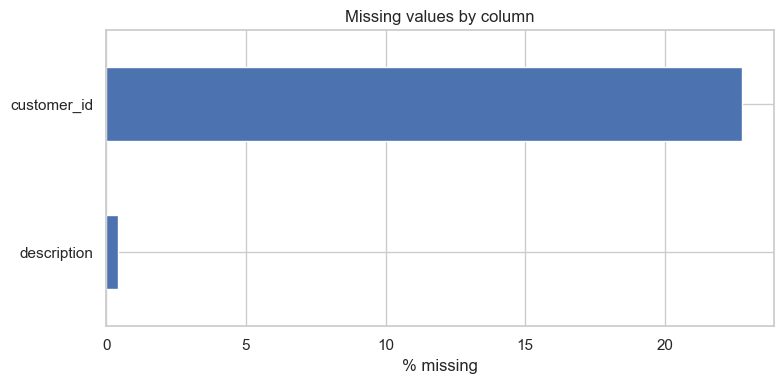

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
missing_pct = missing["missing_pct"]
missing_pct[missing_pct > 0].sort_values().plot(kind="barh", ax=ax, color="#4C72B0")
ax.set_xlabel("% missing")
ax.set_title("Missing values by column")
plt.tight_layout()
plt.show()

## Distribution analysis

### Quantity and unit price

Both fields are known from the dataset documentation to contain negative
values (returns/cancellations show as negative quantity, and some price
entries reflect adjustments). The distributions below keep those values in
to size the cleaning effort, rather than filtering them out first.

In [8]:
df[["quantity", "unit_price"]].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99])

,quantity,unit_price
count,1.067371e+06,1.067371e+06
mean,9.938898e+00,4.649388e+00
std,1.727058e+02,1.235531e+02
min,-8.099500e+04,-5.359436e+04
1%,-3.000000e+00,2.100000e-01
5%,1.000000e+00,4.200000e-01
25%,1.000000e+00,1.250000e+00
50%,3.000000e+00,2.100000e+00
75%,1.000000e+01,4.150000e+00
95%,3.000000e+01,9.950000e+00


In [9]:
negative_qty = (df["quantity"] < 0).sum()
negative_price = (df["unit_price"] < 0).sum()
zero_price = (df["unit_price"] == 0).sum()
print(f"Negative quantity rows: {negative_qty:,} ({negative_qty/len(df)*100:.2f}%)")
print(f"Negative price rows:    {negative_price:,} ({negative_price/len(df)*100:.2f}%)")
print(f"Zero price rows:        {zero_price:,} ({zero_price/len(df)*100:.2f}%)")

Negative quantity rows: 22,950 (2.15%)
Negative price rows:    5 (0.00%)
Zero price rows:        6,202 (0.58%)


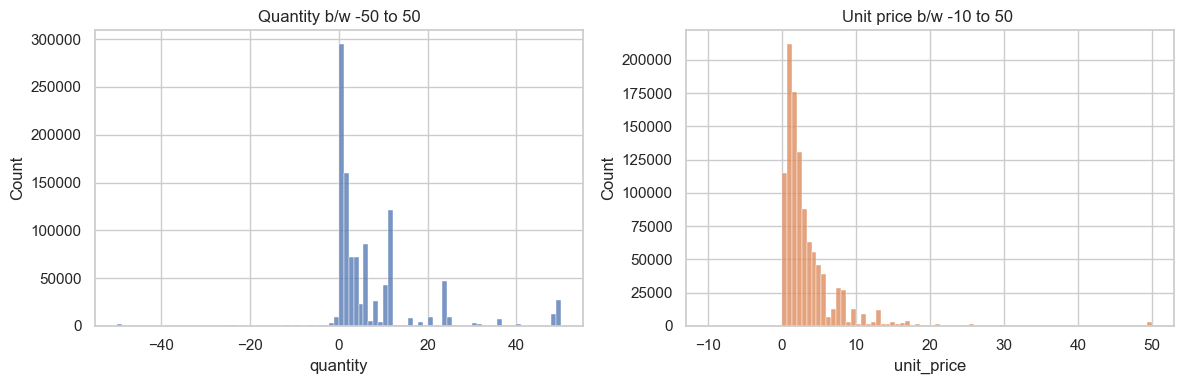

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

qty_clip = df["quantity"].clip(-50, 50)
sns.histplot(qty_clip, bins=90, ax=axes[0], color="#4C72B0")
axes[0].set_title("Quantity b/w -50 to 50")

price_clip = df["unit_price"].clip(-10, 50)
sns.histplot(price_clip, bins=90, ax=axes[1], color="#DD8452")
axes[1].set_title("Unit price b/w -10 to 50 ")

plt.tight_layout()
plt.show()

### Cancellations (Invoice numbers prefixed with 'C')

In [10]:
is_cancellation = df["invoice"].astype(str).str.startswith("C")
print(f"Cancellation line items: {is_cancellation.sum():,} ({is_cancellation.mean()*100:.2f}%)")

Cancellation line items: 19,494 (1.83%)


### Country distribution

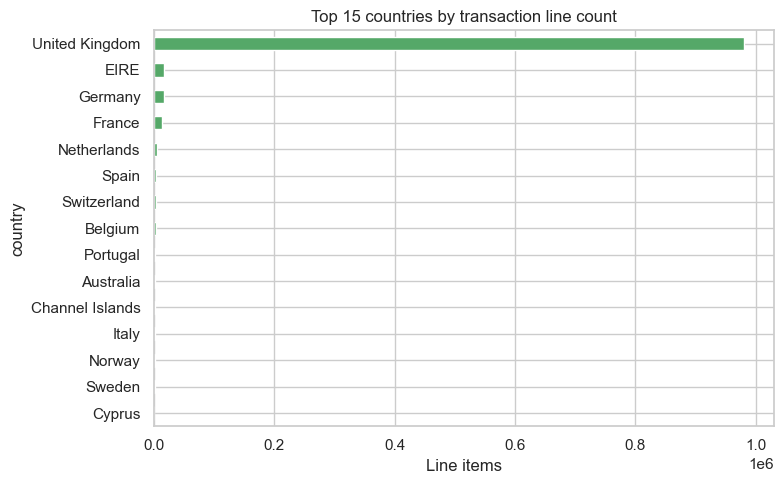

In [11]:
top_countries = df["country"].value_counts().head(15)
fig, ax = plt.subplots(figsize=(8, 5))
top_countries.sort_values().plot(kind="barh", ax=ax, color="#55A868")
ax.set_xlabel("Line items")
ax.set_title("Top 15 countries by transaction line count")
plt.tight_layout()
plt.show()

### Transactions over time

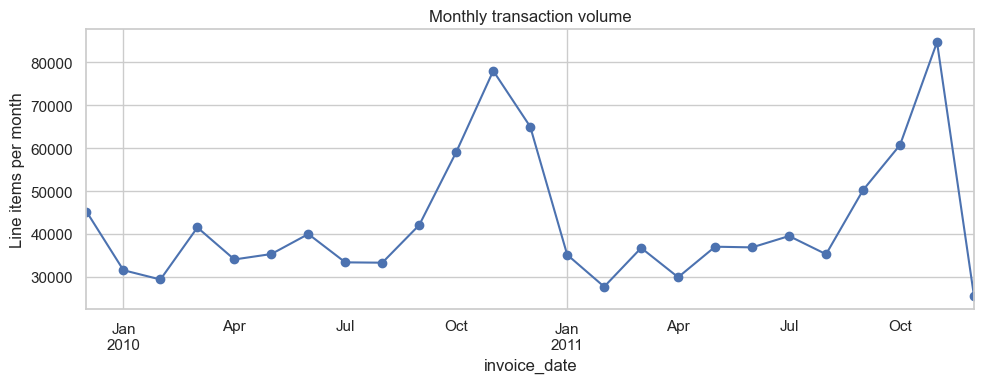

In [12]:
monthly = df.set_index("invoice_date").resample("MS").size()
fig, ax = plt.subplots(figsize=(10, 4))
monthly.plot(ax=ax, marker="o", color="#4C72B0")
ax.set_ylabel("Line items per month")
ax.set_title("Monthly transaction volume")
plt.tight_layout()
plt.show()

## Correlation heatmap


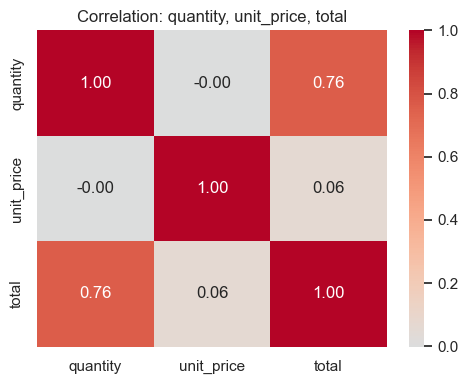

In [13]:
numeric_cols = ["quantity", "unit_price"]
df["total"] = df["quantity"] * df["unit_price"]
numeric_cols.append("total")

corr = df[numeric_cols].corr()
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation: quantity, unit_price, total")
plt.tight_layout()
plt.show()

## Day 1 summary

- Dataset : 1,067,371 line items, 01/12/2009 to 09/12/2011, matches
  UCI documentation exactly.
- `customer_id` column with large missing value; description
  has a small number of nulls too.
- Negative quantities and a `C`-prefixed invoice convention both encode
  cancellations.
- `unit_price` has a meaningful share of zero values.
- Quantity and unit_price show weak linear correlation, consistent with a
  catalog of varied, low-cost gift items where bulk wholesale orders (large
  quantity) and unit price are largely independent.

